# Colouring points in spatialdata-plot

`render_points` colours a point element by any of its columns: a **continuous** column gets a colormap
and a colorbar, a **categorical** column gets a palette and a legend. This tutorial walks through the
point-colouring arguments. By the end you should be able to:

- Colour by a continuous column and shape the mapping with `cmap` and `norm`.
- Colour by a categorical column, set the `palette`, subset with `groups`, and style the rest with
  `na_color`.
- Adjust `size` and `alpha`, and know when to switch to the datashader backend.

We use the real Xenium `cells` dataset from `squidpy` (its `transcripts` element), downloaded and
cached on first use. Point colouring uses the **matplotlib backend** (`method="matplotlib"`) so every
point keeps its own colour; `render_points` otherwise switches to datashader above ~10,000 points, which aggregates them and so
cannot keep a distinct colour per point — see the *Point density maps* and *Speeding up rendering*
notebooks.

## Setup

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sq.datasets.cells()
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


INFO     Loading existing dataset from data/spatialdata/cells.zarr                                                 


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/spatialdata/cells.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     ├── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'tissue_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Lab

The `cells` dataset is a small (~3&thinsp;MB) crop of a real 10x **Xenium** breast-cancer section,
cached locally after the first download. The colouring below draws on the columns of its
`transcripts` points element:

In [2]:
list(sdata["transcripts"].columns)

['x',
 'y',
 'z',
 'feature_name',
 'cell_id',
 'fov_name',
 'codeword_index',
 'qv',
 'transcript_id',
 'is_gene',
 'codeword_category',
 'nucleus_distance',
 'overlaps_nucleus']

## 1. A continuous column — colorbar

Colouring by a continuous column draws a **colorbar**. Each transcript carries a Phred-scaled quality
`qv`; higher is better.

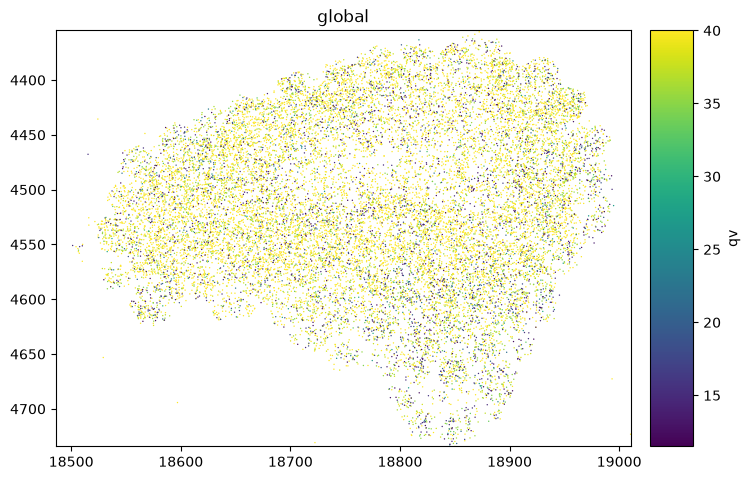

In [3]:
sdata.pl.render_points("transcripts", color="qv", method="matplotlib").pl.show()

## 2. Shaping the continuous mapping — `cmap` and `norm`

Choose a colormap with `cmap`, and pin the contrast window with `norm` (see the *Normalization and
contrast* tutorial). Here we highlight transcripts within 15&thinsp;px of a nucleus.

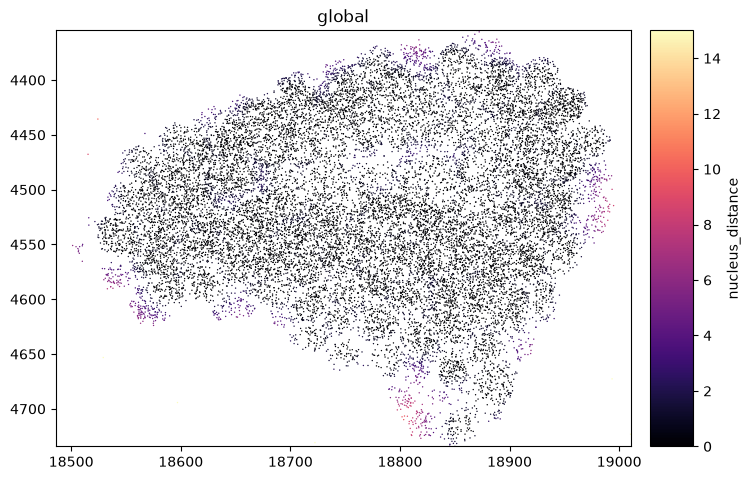

In [4]:
from matplotlib.colors import Normalize

sdata.pl.render_points(
    "transcripts",
    color="nucleus_distance",
    cmap="magma",
    norm=Normalize(0, 15),
    method="matplotlib",
).pl.show()

## 3. A categorical column — legend and `palette`

A categorical column draws a **legend**. `overlaps_nucleus` is a clean two-category flag; `palette`
assigns the colours.

WARNING  render_points: Ignoring categorical palette which is given for a continuous variable. Consider using      
         `cmap` to pass a ColorMap.                                                                                


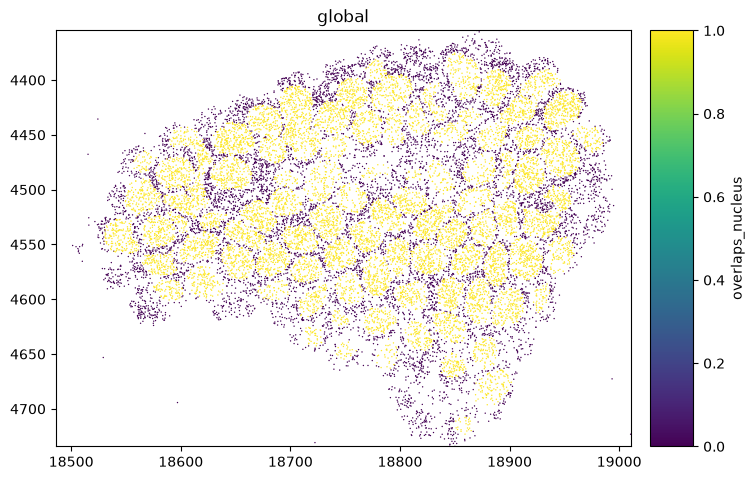

In [5]:
sdata.pl.render_points(
    "transcripts",
    color="overlaps_nucleus",
    palette=["lightgrey", "crimson"],
    method="matplotlib",
).pl.show()

## 4. Subsetting categories — `groups` and `na_color`

`groups` restricts colouring to selected categories; everything else is drawn in `na_color`. Here we
pick a few marker genes and grey out the rest. Omit `na_color` and the non-matching points are hidden
entirely instead of greyed.

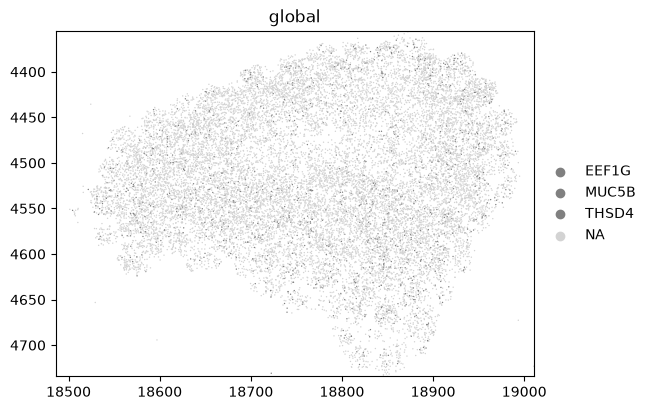

In [6]:
sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["MUC5B", "EEF1G", "THSD4"],
    na_color="lightgrey",
    method="matplotlib",
).pl.show()

## 5. Marker size and opacity — `size`, `alpha`

`size` scales the markers and `alpha` sets their opacity — lower both to reveal density where points
pile up.

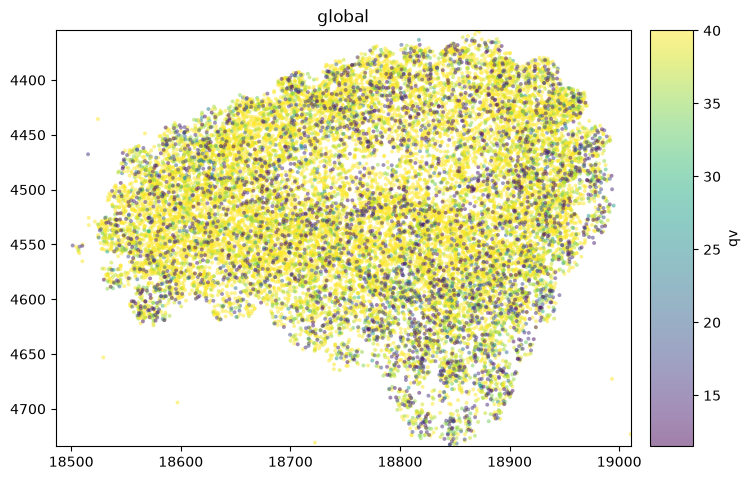

In [7]:
sdata.pl.render_points(
    "transcripts", color="qv", size=8, alpha=0.5, method="matplotlib"
).pl.show()

## Summary

- A **continuous** `color=` column draws a colorbar; shape it with `cmap` and `norm`.
- A **categorical** `color=` column draws a legend; set colours with `palette`, subset with `groups`,
  and style the remainder with `na_color`.
- `size` and `alpha` tune the markers.
- Per-point colouring uses the matplotlib backend; `render_points` auto-switches to datashader above
  10,000 points (which drops per-point colour), so pass `method="matplotlib"` to force it — or reach
  for datashader deliberately (`method="datashader"`, or `density=True`) for millions of points. See
  the *Point density maps* and *Speeding up rendering* notebooks.

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
matplotlib      : 3.11.0
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

